In [35]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [36]:
#Load Dataset
df = pd.read_csv(r"C:\Users\ACER\Downloads\archive (4)\medical_cost_prediction_dataset.csv")


In [37]:
df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,Male,29.4,No,1,0,0,0,Medium,14825,4.4,8,1,0,4,Private,80,Semi-Urban,10885,2645.50
1,32,Female,22.9,No,1,0,0,0,Medium,3620,6.0,7,4,3,0,Government,64,Semi-Urban,18722,10959.70
2,89,Male,25.7,No,0,0,0,0,High,10578,4.5,7,2,0,3,NaN,0,Urban,4196,8409.80
3,78,Male,31.9,Yes,0,1,0,0,Low,6226,8.6,9,6,1,7,Government,70,Urban,11128,7996.62
4,38,Male,27.7,No,0,0,0,0,High,6253,5.7,3,6,0,6,Private,77,Urban,15110,3202.52


In [38]:
df.tail()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
4995,77,Female,19.7,Yes,0,0,0,0,Low,7825,5.7,3,3,0,4,Government,77,Semi-Urban,17154,3513.76
4996,43,Female,23.9,Yes,0,0,0,0,Medium,9054,8.4,7,4,0,1,NaN,0,Urban,4797,9816.10
4997,58,Female,31.1,No,0,0,0,0,Medium,6299,6.7,3,6,1,2,Private,81,Semi-Urban,16543,3354.62
4998,53,Male,27.6,No,0,0,0,0,Medium,8379,6.2,8,4,0,4,Private,88,Urban,11310,1401.72
4999,40,Male,25.8,No,0,0,0,0,Low,2000,5.3,5,2,1,4,Government,63,Urban,17078,6548.04


In [39]:
df.shape

(5000, 20)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   gender                   5000 non-null   object 
 2   bmi                      5000 non-null   float64
 3   smoker                   5000 non-null   object 
 4   diabetes                 5000 non-null   int64  
 5   hypertension             5000 non-null   int64  
 6   heart_disease            5000 non-null   int64  
 7   asthma                   5000 non-null   int64  
 8   physical_activity_level  5000 non-null   object 
 9   daily_steps              5000 non-null   int64  
 10  sleep_hours              5000 non-null   float64
 11  stress_level             5000 non-null   int64  
 12  doctor_visits_per_year   5000 non-null   int64  
 13  hospital_admissions      5000 non-null   int64  
 14  medication_count        

In [41]:
df.isnull().sum()

age                           0
gender                        0
bmi                           0
smoker                        0
diabetes                      0
hypertension                  0
heart_disease                 0
asthma                        0
physical_activity_level       0
daily_steps                   0
sleep_hours                   0
stress_level                  0
doctor_visits_per_year        0
hospital_admissions           0
medication_count              0
insurance_type             1048
insurance_coverage_pct        0
city_type                     0
previous_year_cost            0
annual_medical_cost           0
dtype: int64

In [42]:
df = df.dropna()

In [43]:
df.isnull().sum()

age                        0
gender                     0
bmi                        0
smoker                     0
diabetes                   0
hypertension               0
heart_disease              0
asthma                     0
physical_activity_level    0
daily_steps                0
sleep_hours                0
stress_level               0
doctor_visits_per_year     0
hospital_admissions        0
medication_count           0
insurance_type             0
insurance_coverage_pct     0
city_type                  0
previous_year_cost         0
annual_medical_cost        0
dtype: int64

In [44]:
#Convert Text Columns to Numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [45]:
df.head()

,age,gender,bmi,smoker,diabetes,hypertension,heart_disease,asthma,physical_activity_level,daily_steps,sleep_hours,stress_level,doctor_visits_per_year,hospital_admissions,medication_count,insurance_type,insurance_coverage_pct,city_type,previous_year_cost,annual_medical_cost
0,69,1,29.4,0,1,0,0,0,2,14825,4.4,8,1,0,4,1,80,1,10885,2645.50
1,32,0,22.9,0,1,0,0,0,2,3620,6.0,7,4,3,0,0,64,1,18722,10959.70
3,78,1,31.9,1,0,1,0,0,1,6226,8.6,9,6,1,7,0,70,2,11128,7996.62
4,38,1,27.7,0,0,0,0,0,0,6253,5.7,3,6,0,6,1,77,2,15110,3202.52
5,41,1,25.7,0,0,0,0,0,2,14720,7.7,10,5,2,6,1,89,2,18459,3072.16


In [46]:
#Important Graphs

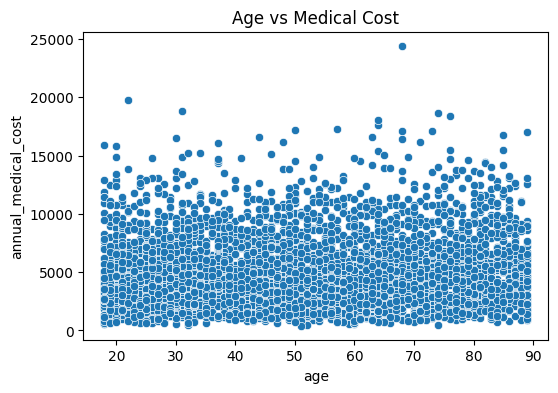

In [47]:
#Age vs Medical Cost
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['age'], y=df['annual_medical_cost'])
plt.title("Age vs Medical Cost")
plt.show()

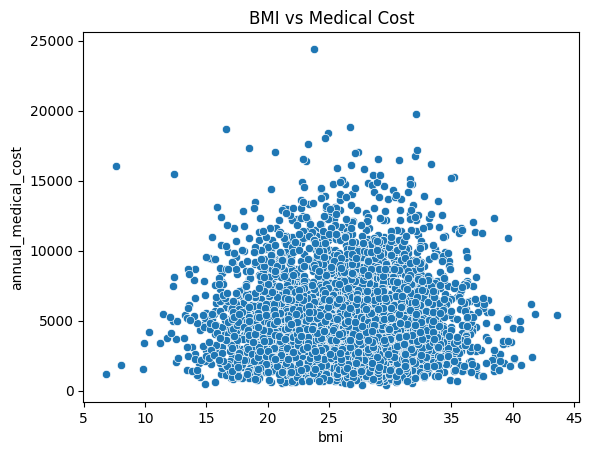

In [48]:
#BMI vs Medical Cost
sns.scatterplot(x=df['bmi'], y=df['annual_medical_cost'])
plt.title("BMI vs Medical Cost")
plt.show()

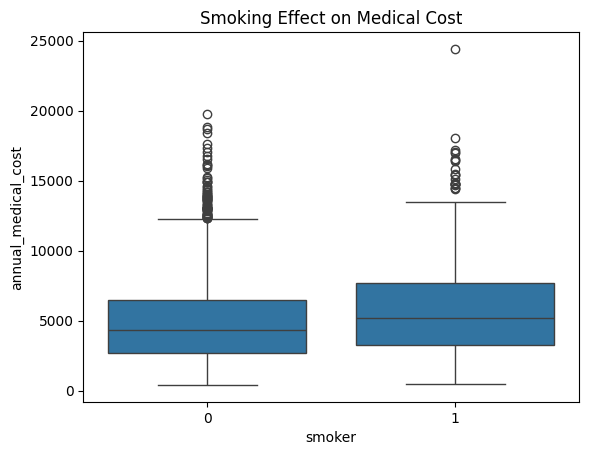

In [49]:
#Smoking vs Cost
sns.boxplot(x=df['smoker'], y=df['annual_medical_cost'])
plt.title("Smoking Effect on Medical Cost")
plt.show()

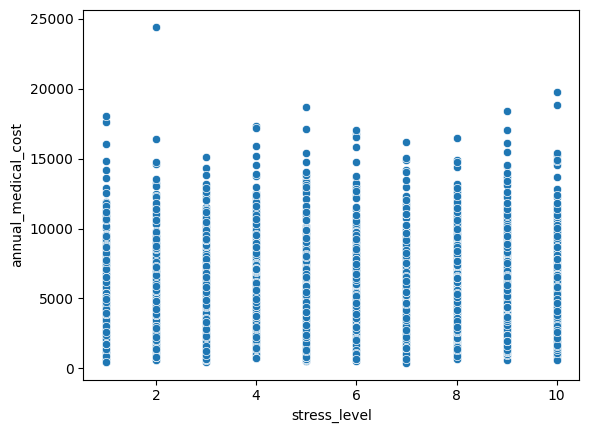

In [50]:
#Stress Level vs Cost
sns.scatterplot(x=df['stress_level'], y=df['annual_medical_cost'])
plt.show()

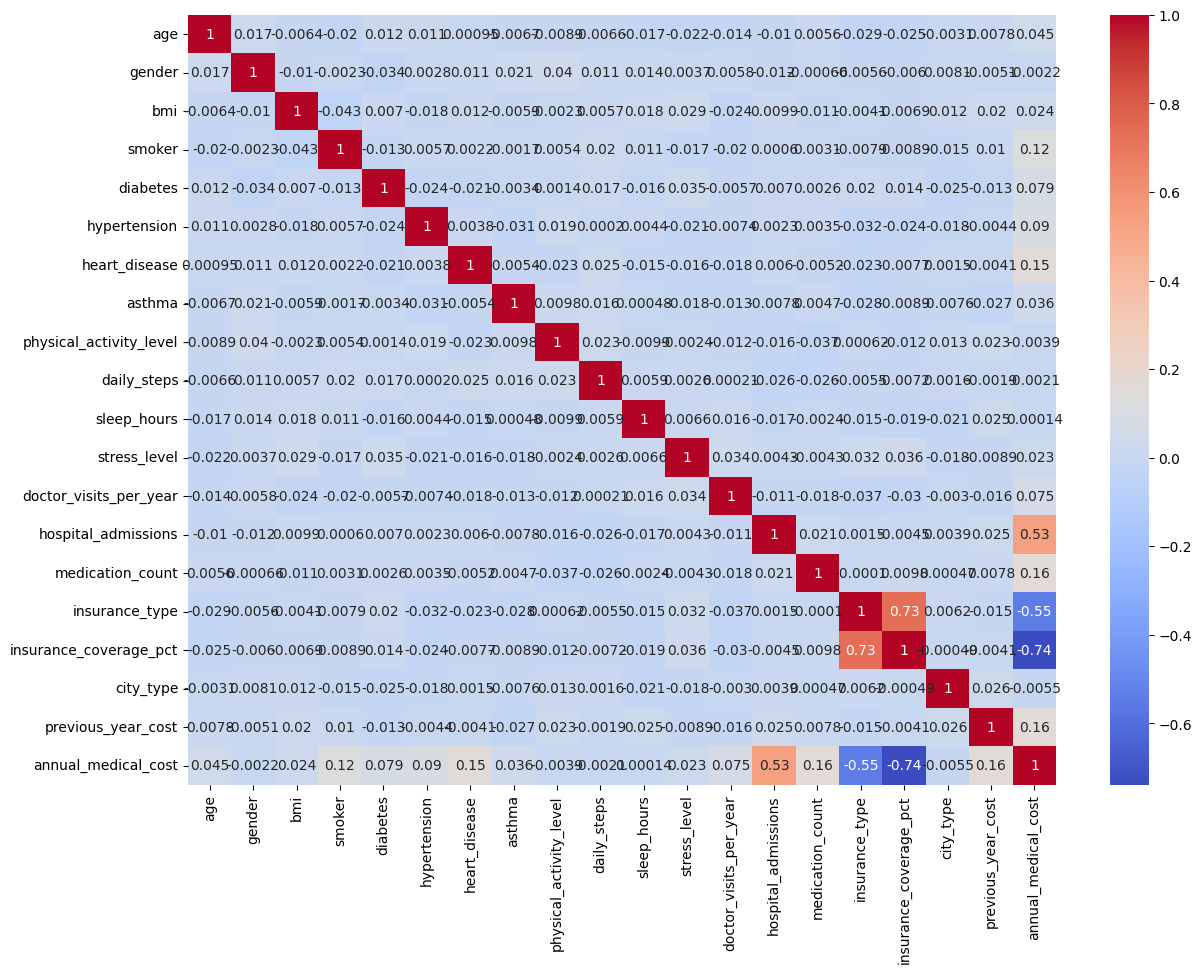

In [51]:
#Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [52]:
#Define Input and Output Variables

In [53]:
#Target column:
y = df['annual_medical_cost']

In [54]:
#Features:
X = df.drop('annual_medical_cost', axis=1)

In [55]:
#Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [56]:
#Train Model (Linear Regression)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
#Predict Insurance Cost
predictions = model.predict(X_test)

In [58]:
#Check Accuracy
from sklearn.metrics import r2_score, mean_absolute_error

r2_score(y_test, predictions)

0.9284856959272021

In [59]:
#Check prediction error:
mean_absolute_error(y_test, predictions)

518.4174339052528

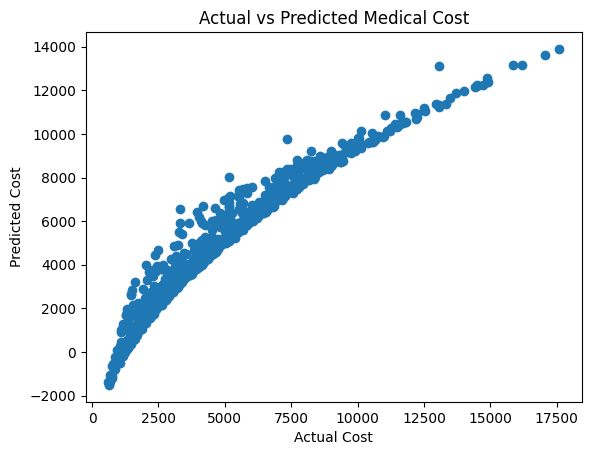

In [60]:
#Actual vs Predicted Graph
plt.scatter(y_test, predictions)
plt.xlabel("Actual Cost")
plt.ylabel("Predicted Cost")
plt.title("Actual vs Predicted Medical Cost")
plt.show()

In [61]:
#Advanced Model
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

r2_score(y_test, rf_pred)

0.9551703932686083

In [62]:
#Random Forest model produced higher prediction accuracy compared to Linear Regression.

In [63]:
#Example
new_person = [[
    40,    # age
    1,     # gender
    27.5,  # bmi
    0,     # smoker
    0,     # diabetes
    1,     # hypertension
    0,     # heart_disease
    0,     # asthma
    1,     # physical_activity
    7000,  # daily_steps
    7,     # sleep_hours
    6,     # stress_level
    2,     # doctor_visits
    1,     # hospital_admissions
    1,     # medication
    2,     # insurance_type
    80,    # insurance_coverage  
    1,     # city_type
    4500   # previous_cost
]]

predicted_cost = model.predict(new_person)

print("Predicted Medical Insurance Cost =", predicted_cost[0])

Predicted Medical Insurance Cost = 2403.5394794943386


C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
